# Plots Master

Run any plot you need, only run setup and the window you are interested in.
Choose the data from the dropdown menu and adjust global parameters in setup, if needed.

In [2]:
#general imports
# import h5py
# import meteor
# import reciprocalspaceship as rs
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

import os
import sys
current_path = os.getcwd()
path_parts = current_path.split(os.sep)
idx = path_parts.index("occupancy-estimation")
homepath = os.sep.join(path_parts[:idx + 1])
sys.path.append(homepath)

# my imports
from occupancy import *
from plotting3d import *
from generate_objects import *
from logger import setup_logger

logger = setup_logger()


no interactive widgets for you


In [1]:
%load_ext autoreload 
%autoreload 2

In [3]:
# # "Latex style"
# import matplotlib
# matplotlib.rcParams.update({
#     "font.family": "serif",
#     "text.usetex": True,
# }
# )

# Setup

In [9]:
from scipy.ndimage import binary_dilation


In [ ]:


def plot_zero_crossover(diffmap, obj0, alpha, thresh=0, title="", mask=None):
    negmask = diffmap < thresh
    # negmask = diffmap <-4e-2
    posmask = binary_dilation(diffmap > 5e-4, iterations=1)
    subset = np.logical_and(negmask, ~posmask)
    antisub = np.logical_and(negmask, posmask)

    fig, axso = plt.subplots(2,2, figsize=(10,5), tight_layout=True)
    axs = axso.flat
    for ax in axs[:2]:
        ax.axhline(1/alpha, c="red", label="1/alpha", alpha=0.5)
        ax.set_xlabel("Diffmap Value (negatives)")
    # neggest_value = diffmap[negmask][idx]
    # neggest_div = division[idx]
    # top = 1e8
    # ax.plot([-neggest_value, 1/top], [neggest_div, neggest_div*top], 'k--', alpha=0.5)
    division = obj0[negmask]/-diffmap[negmask]
    divsub = obj0[subset]/-diffmap[subset]
    divanti = obj0[antisub]/-diffmap[antisub]
    ax  = axs[0]
    ax.plot(-diffmap[subset], divsub, ".", alpha=0.2)
    ax.plot(-diffmap[antisub], divanti, ".", alpha=0.05)
    
    ax.set_title(title)
    ax.set_xlim(1e-10,5)
    ax.set_ylim(1e-9,1e8)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylabel(r"$\frac{F_0}{\Delta F}$ = Occupancy Estimate")

    ax  = axs[1]
    # ax.plot(-diffmap[negmask], division, ".", alpha=0.2)

    
    ax.plot(-diffmap[subset], divsub, ".", alpha=0.2)
    ax.plot(-diffmap[antisub], divanti, ".", alpha=0.2)
    ax.set_ylim(0.1,1/alpha*2.5)
    ax.set_xlim(1e-4,np.max(-diffmap[negmask])*1.01)
    total_diff = np.average(division, weights=np.abs(diffmap[negmask])**2)
    subdiff = np.average(divsub, weights=np.abs(diffmap[subset])**2)
    ax.axhline(total_diff, c="green", linestyle="--", label=f"Total avg: {total_diff:.2f}")
    ax.axhline(subdiff, c="blue", linestyle="--", label=f"Subset avg: {subdiff:.2f}")
    

    ax.set_xscale("linear")
    ax.set_title("Zoomed in")
    ax.set_ylabel(r"$\frac{F_0}{\Delta F}$ = Occupancy Estimate")
    ax.legend()

    ax = axs[2]
    ax.plot(-diffmap[negmask], obj0[negmask], ',', alpha=1)
    ax.set_ylabel("Known state $F_0$")
    ax.set_xlabel("Diffmap $\Delta F$")

    ax = axs[3]
    ax.set_title(f"outliers removed: {np.sum((1/division)>1)},{np.sum(division==0)} ")
    ax.plot(-diffmap[negmask], 1/division, ".", alpha=0.2)
    ax.axhline(alpha, c="red", label="alpha")
    ax.set_ylabel("Occupancy")
    ax.set_xlabel("Diffmap $\Delta F$")
    ax.set_ylim(0, 1.)

    plt.show()
    return fig

def calc_alpha_from_cov(xm, x0):
    """
    xm: mixed distribution (obj0 + diffmap)
    x0: original distribution (obj0)

    Underlying assumption: same marginal variance
    xm = (1-alpha)*x0 + alpha*x1
    """
    var0 = np.var(x0, ddof=0)
    cov  = np.cov(xm, x0, ddof=0)[0,1]
    beta = cov / var0
    k    = np.var(xm, ddof=0) / var0

    # the derivation for this is a bit lengthy
    # but is the endproduct of solving xm = (1-alpha)*x0 + alpha*x1 for alpha 
    # using var0 and cov
    alpha_hat = (k + 1 - 2*beta) / (2 * (1 - beta))

    # measure of correlation
    # uncorrelated would be easiest but either we have high correlation (no mask)
    # or we have high negative correlation (with mask)
    r_hat = (-2*beta**2 + 2*beta + k - 1) / (-2*beta + k + 1)
    print(f"alpha: {alpha_hat}, r: {r_hat}")


<>:56: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:63: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:56: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:63: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
/var/folders/8v/lr399fkd51jglh0scs3jsz540000gn/T/ipykernel_20250/3595308797.py:56: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  ax.set_xlabel("Diffmap $\Delta F$")
/var/folders/8v/lr399fkd51jglh0scs3jsz540000gn/T/ipykernel_20250/3595308797.py:63: SyntaxWarning: "\D" is an invalid

In [6]:
alpha = 0.3

# foldername = get_base_folder() + "/../nse_text/figs/"
noise_level = 0.0
offset= False
# calc_with_ints = False
# ylog = True
# # obj0, obj1, f_dark, f_light,_,_  =  generate_obj_cistrans_v2(alpha, noise_level, phi_noise=0 ,no_negs=bool(offset), scaleit=False, hs_limit=2)
obj0, obj1, f_dark, f_light  =  generate_obj_cistrans_v5(alpha, noise_level, phi_noise=0 ,no_negs=bool(offset), scaleit=False, hs_limit=1.5)
diffmap = obj1-obj0
# delta_f_with_phase = np.fft.fftn(diffmap)
# diffmap = np.fft.ifftn(delta_f_with_phase).real
# thresh = np.std(diffmap)*1
# fig = plot_zero_crossover(diffmap, obj0, alpha, thresh=0, title="Clean Intensities")

# filename = foldername +"zero_crossover_clean.pdf"
# fig.savefig(filename)


# negmask = diffmap <-0
# rho0 = (obj0).flatten()
# rhomix = (obj0+diffmap).flatten()
# # np.save("rho0_no_noise.npy", rho0)
# # np.save("rhomix_no_noise.npy", rhomix)
# calc_alpha_from_cov((obj0+diffmap).flatten(), rho0)


In [27]:
from scipy.ndimage import convolve
loc = "/Users/sbielfel/Dropbox/Apps/Overleaf/Occupancy Determination/figs/"
def plot_zero_crossover2(diffmap, obj0, alpha, thresh=1, posmask_thresh=1., title="", mask=None, figname=None, ax = None):
    negmask = diffmap < thresh
    # negmask = diffmap <-4e-2
    posmask = binary_dilation(diffmap > posmask_thresh, iterations=2)
    neighborhood_kernel = np.ones((5,5,5))
    positive_data = np.maximum(diffmap, 0)
    result = convolve(positive_data, neighborhood_kernel, mode='wrap')
    result_perc = np.percentile( result, 90)
    posmask = result > result_perc
    if posmask_thresh==1:
        posmask = False
    subset = np.logical_and(negmask, ~posmask)
    antisub = np.logical_and(negmask, posmask)

    if ax is None:
      fig, ax = plt.subplots(1,1, figsize=(8,5), tight_layout=True)
    else:
      fig = ax.get_figure()

    ax.set_xlabel("Diffmap Value (negatives)")
    # neggest_value = diffmap[negmask][idx]
    # neggest_div = division[idx]
    # top = 1e8
    # ax.plot([-neggest_value, 1/top], [neggest_div, neggest_div*top], 'k--', alpha=0.5)
    division = obj0[negmask]/-diffmap[negmask]
    divsub = obj0[subset]/-diffmap[subset]
    divanti = obj0[antisub]/-diffmap[antisub]
    if antisub.sum()>0:
      ax.plot(
          diffmap[antisub], 
          1/divanti,
            ".", alpha=0.3, label="Voxels near positive peaks",
            color='orange'
            )
    ax.plot(
        diffmap[subset], 
        1/divsub,
          ".", alpha=0.3, label="Voxel estimates",
          color='blue')
    # ax.plot(-diffmap[subset], divsub, ".", alpha=0.2, label="voxels to ")
    # ax.plot(
    #     1/division, 
    #     -diffmap[negmask], 
    #     ".", alpha=0.2, label="voxels to ")
    ax.axhline(alpha, c="red", label="True occupancy", alpha=0.5)

    # ax.plot(-diffmap[antisub], divanti, ".", alpha=0.2)
    
    ax.set_title(title)
    # ax.set_xlim(1e-10,1e3)
    # ax.set_ylim(1e-9,1e3)
    ax.set_xlabel("Diffmap Value (negatives)", fontsize= 18)
    ax.set_ylabel(r"$\frac{-\Delta \rho}{\rho_0}$ = Occupancy Estimate", fontsize= 18)
    ax.legend()
    ax.set_ylim(0, alpha*1.5)
    if figname is not None:
        fig.savefig(loc + figname)
    

# %%


/var/folders/8v/lr399fkd51jglh0scs3jsz540000gn/T/ipykernel_22496/3395491731.py:14: DeprecationWarning: Bitwise inversion '~' on bool is deprecated and will be removed in Python 3.16. This returns the bitwise inversion of the underlying int object and is usually not what you expect from negating a bool. Use the 'not' operator for boolean negation or ~int(x) if you really want the bitwise inversion of the underlying int.
  subset = np.logical_and(negmask, ~posmask)
/var/folders/8v/lr399fkd51jglh0scs3jsz540000gn/T/ipykernel_22496/3395491731.py:33: RuntimeWarning: divide by zero encountered in divide
  1/divanti,
/var/folders/8v/lr399fkd51jglh0scs3jsz540000gn/T/ipykernel_22496/3395491731.py:39: RuntimeWarning: divide by zero encountered in divide
  1/divsub,


/Users/sbielfel/Dropbox/Apps/Overleaf/Occupancy Determination/figs/
/Users/sbielfel/Dropbox/Apps/Overleaf/Occupancy Determination/figs/cistrans_comparison.png


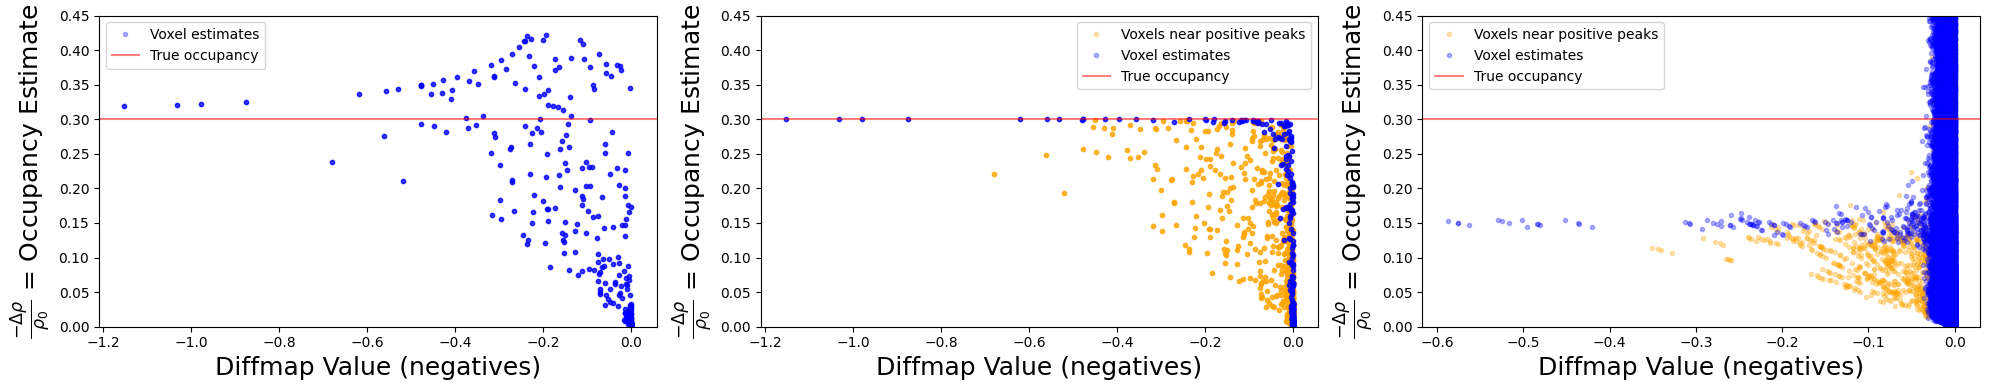

In [30]:
fig,axs = plt.subplots(1,3,figsize=(20,4), tight_layout=True)
axs = axs.flat
diffmap_sf=np.fft.fft2(diffmap)
obj0_sf=np.fft.fft2(obj0)
diffmap_conj_phases = np.angle(np.conjugate(diffmap))+2*np.angle(obj0_sf)
diffmap_conj_sf = np.abs(diffmap_sf)*np.exp(1j*diffmap_conj_phases)
diffmap_conj = np.fft.ifft2(diffmap_conj_sf).real
# fig = plot_zero_crossover2(diffmap, obj0, alpha, thresh=0, ax=axs[0])
_ = plot_zero_crossover2(diffmap, obj0-np.mean(obj0), alpha, thresh=0, ax=axs[0])
_ = plot_zero_crossover2(diffmap, obj0, alpha, thresh=0, posmask_thresh=0.1, ax=axs[1])
# _ = plot_zero_crossover2(diffmap + np.random.normal(size=diffmap.shape)*np.max(diffmap)/30, obj0, alpha, thresh=0, posmask_thresh=0.1, ax=axs[2])
_ = plot_zero_crossover2((diffmap + diffmap_conj)/2, obj0, alpha, thresh=0, posmask_thresh=0.1, ax=axs[2])
print(loc)
fileloc = loc + "cistrans_comparison.png"
fig.savefig(fileloc)
print(fileloc)

/var/folders/8v/lr399fkd51jglh0scs3jsz540000gn/T/ipykernel_22496/572389883.py:15: DeprecationWarning: Bitwise inversion '~' on bool is deprecated and will be removed in Python 3.16. This returns the bitwise inversion of the underlying int object and is usually not what you expect from negating a bool. Use the 'not' operator for boolean negation or ~int(x) if you really want the bitwise inversion of the underlying int.
  subset = np.logical_and(negmask, ~posmask)
/var/folders/8v/lr399fkd51jglh0scs3jsz540000gn/T/ipykernel_22496/572389883.py:34: RuntimeWarning: divide by zero encountered in divide
  1/divanti,
/var/folders/8v/lr399fkd51jglh0scs3jsz540000gn/T/ipykernel_22496/572389883.py:40: RuntimeWarning: divide by zero encountered in divide
  1/divsub,


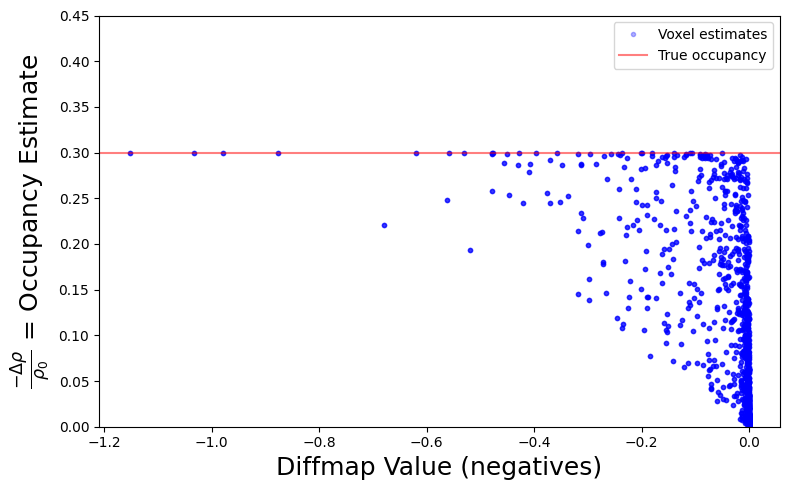

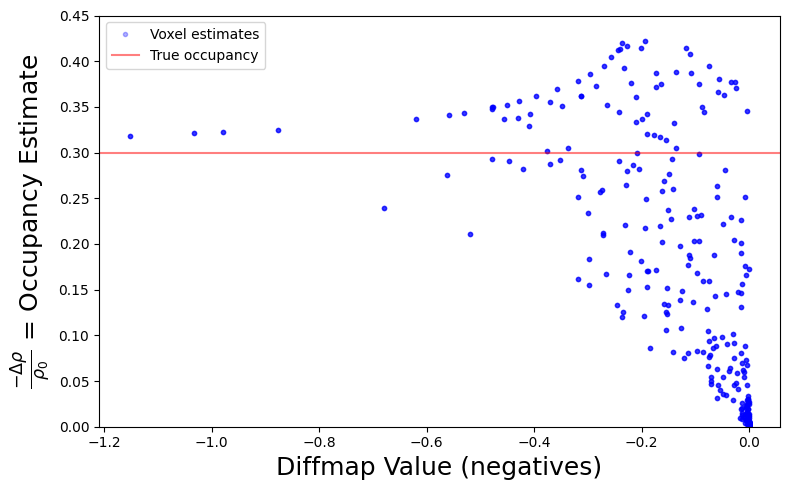

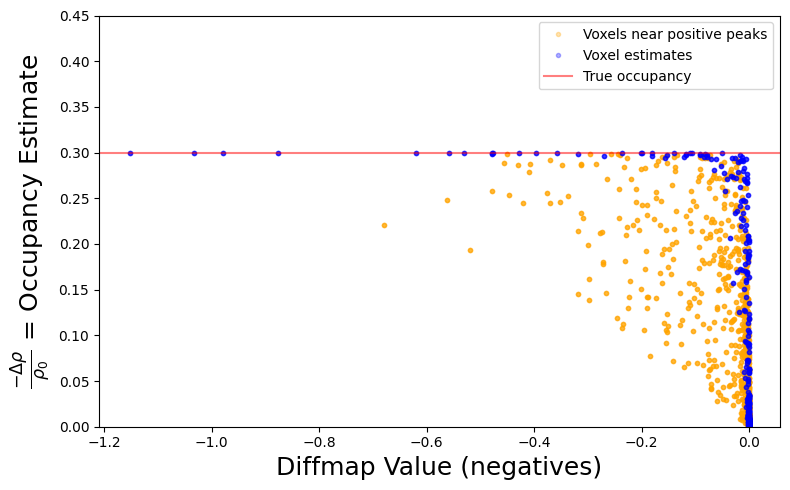

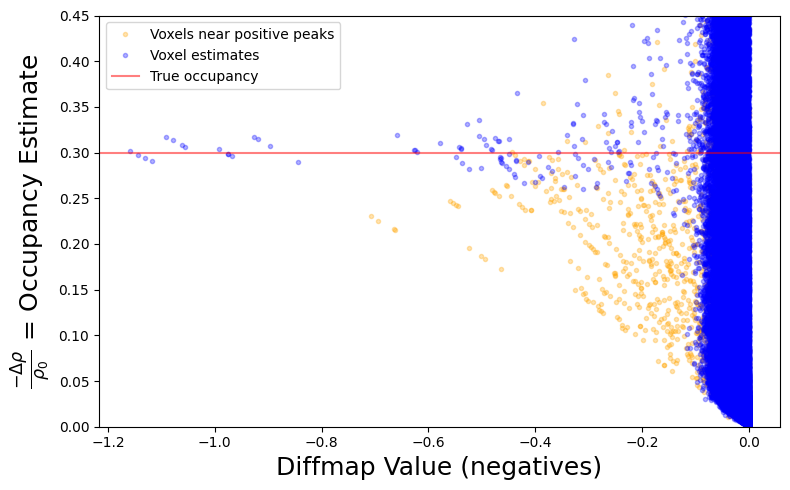

In [ ]:

fig = plot_zero_crossover2(diffmap, obj0, alpha, thresh=0, figname="cistrans_vacuum.png")
fig = plot_zero_crossover2(diffmap, obj0-np.mean(obj0), alpha, thresh=0, figname="cistrans_mean.png")
fig = plot_zero_crossover2(diffmap, obj0, alpha, thresh=0, posmask_thresh=0.1, figname="cistrans_vacuum_masked.png")
fig = plot_zero_crossover2(diffmap + np.random.normal(size=diffmap.shape)*np.max(diffmap)/30, obj0, alpha, thresh=0, posmask_thresh=0.1, figname="cistrans_noisy_masked.png")


(72, 90, 100)
(72, 90, 100)


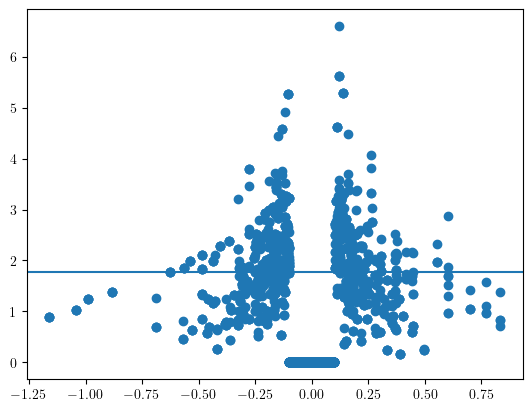

/var/folders/pr/w1s1g8813qn100g39nl2z99m0000gp/T/ipykernel_76473/3502935608.py:31: RuntimeWarning: divide by zero encountered in divide
  occu_subset = -diffmap[subset]/obj0[subset]


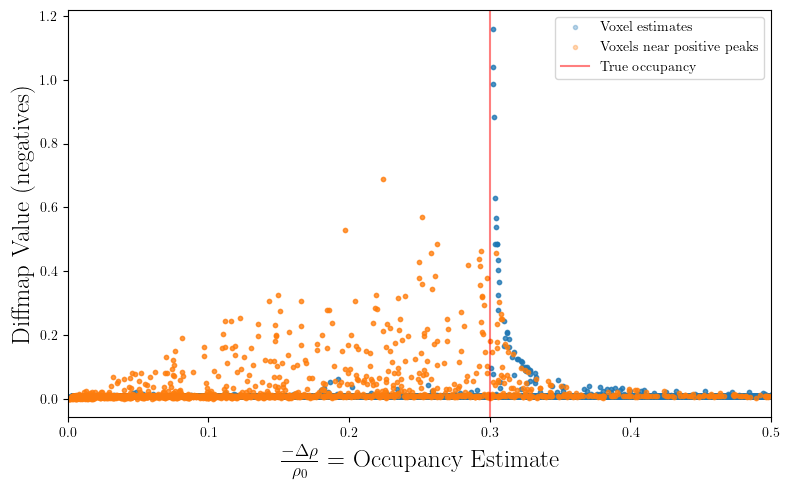

In [8]:
def plot_zero_crossover3(diffmap, obj0, alpha, estimate, thresh=0, posmask_thresh=1, title="", mask=None):
    negmask = diffmap < thresh
    # negmask = diffmap <-4e-2
    diffmap_grad = np.sum(np.abs(np.gradient(diffmap)), axis=0) /(np.log(np.abs(diffmap)+1))
    diffmap_grad[np.abs(diffmap)<0.1]=0
    print(diffmap_grad.shape)
    print(diffmap.shape)
    diffmap_grad_perc = np.percentile( np.abs(diffmap_grad), 99.9)
    plt.scatter(diffmap.flatten(), diffmap_grad.flatten(), )
    plt.axhline(diffmap_grad_perc)
    plt.show()
    # mask_np = np.logical_and([np.abs(diffmap_grad) > diffmap_grad], mask_np)
    posmask = np.abs(diffmap_grad) > diffmap_grad_perc
    from scipy.ndimage import convolve
    neighborhood_kernel = np.ones((5,5,5))
    positive_data = np.maximum(diffmap, 0)
    result = convolve(positive_data, neighborhood_kernel, mode='wrap')
    result_perc = np.percentile( result, 90)
    posmask = result > result_perc

    subset = np.logical_and(negmask, ~posmask)
    antisub = np.logical_and(negmask, posmask)

    fig, ax = plt.subplots(1,1, figsize=(8,5), tight_layout=True)
    ax.set_xlabel("Diffmap Value (negatives)")
    # neggest_value = diffmap[negmask][idx]
    # neggest_div = division[idx]
    # top = 1e8
    # ax.plot([-neggest_value, 1/top], [neggest_div, neggest_div*top], 'k--', alpha=0.5)
    division = obj0[negmask]/-diffmap[negmask]
    occu_subset = -diffmap[subset]/obj0[subset]
    occu_antisubset = -diffmap[antisub]/obj0[antisub]

    ax.plot(
        occu_subset,
        -diffmap[subset], 
          ".", alpha=0.3, label="Voxel estimates")
    if antisub.sum()>0:
      ax.plot(
          occu_antisubset,
          -diffmap[antisub], 
            ".", alpha=0.3, label="Voxels near positive peaks ")
    else:
      print("nada")
    # ax.plot(-diffmap[subset], divsub, ".", alpha=0.2, label="voxels to ")
    # ax.plot(
    #     1/division, 
    #     -diffmap[negmask], 
    #     ".", alpha=0.2, label="voxels to ")
    ax.axvline(alpha, c="red", label="True occupancy", alpha=0.5)

    # occu_finite = np.logical_and(~np.isnan(occu_subset), occu_subset<np.inf)
    # estimated_occu = np.average(occu_subset[occu_finite], weights=np.abs(diffmap[subset][occu_finite]))
    # # estimated_occu = np.mean(occu_subset[occu_finite])
    # xtr = 1/estimate*diffmap[subset]-obj0[subset]+np.random.normal(size=np.sum(subset))*np.max(obj0)/300
    # # xtr = 1/0.2*diffmap[subset]-obj0[subset]
    # occu_subset_2 = diffmap[subset]/(obj0[subset] + xtr)
    # # occu_subset_2 = diffmap[subset]/(diffmap[subset]/.2)
    # # occu_subset_2 = 1/.2
    
    # ax.plot(
    #     occu_subset_2,
    #     -diffmap[subset], 
    #       ".", alpha=0.25, label="Voxel corrected", color="green")
    # print(f"Estimated occupancy: {estimated_occu}")

    # ax.plot(-diffmap[antisub], divanti, ".", alpha=0.2)
    
    ax.set_title(title)
    ax.set_xlim(0.,0.5)
    # ax.set_xlim(-4.,3)
    # ax.set_ylim(1e-9,1e3)
    ax.set_ylabel("Diffmap Value (negatives)", fontsize= 18)
    ax.set_xlabel(r"$\frac{-\Delta \rho}{\rho_0}$ = Occupancy Estimate", fontsize= 18)
    ax.legend()
    # ax.set_xlim(0, alpha*1.5)
    plt.show()
    # plt.figure()
    # plt.hist(occu_subset, bins=50, )
    # plt.yscale("log")
    # plt.show()

estimate = 0.2
fig = plot_zero_crossover3(diffmap-np.max(diffmap)*0.01, obj0, alpha, estimate, thresh=0, )
# fig = plot_zero_crossover2(diffmap, obj0-np.mean(obj0), alpha, thresh=0, estimate=estimate)
# fig = plot_zero_crossover2(diffmap, obj0, alpha, thresh=0, posmask_thresh=0.1)
# estimate = 0.2
# fig = plot_zero_crossover3(diffmap + np.random.normal(size=diffmap.shape)*np.max(diffmap)/30, obj0, alpha,  estimate,thresh=0, posmask_thresh=0.0)
# estimate = 0.3
# fig = plot_zero_crossover3(diffmap + np.random.normal(size=diffmap.shape)*np.max(diffmap)/30, obj0, alpha,  estimate,thresh=0, posmask_thresh=0.0)



In [ ]:
+np.max(diffmap)*0.001, obj0, alpha, estimate, thresh=0, )
# fig = plot_zero_crossover2(diffmap, obj0-np.mean(obj0), alpha, thresh=0, estimate=estimate)
# fig = plot_zero_crossover2(diffmap, obj0, alpha, thresh=0, posmask_thresh=0.1)
# estimate = 0.2
# fig = plot_zero_crossover3(diffmap + np.random.normal(size=diffmap.shape)*np.max(diffmap)/30, obj0, alpha,  estimate,thresh=0, posmask_thresh=0.0)
# estimate = 0.3
# fig = plot_zero_crossover3(diffmap + np.random.normal(size=diffmap.shape)*np.max(diffmap)/30, obj0, alpha,  estimate,thresh=0, posmask_thresh=0.0)



In [76]:
ap[subset]/(obj0[subset] - xtr)
    
    ax.plot(
        occu_subset_2,
        -diffmap[subset], 
          ".", alpha=0.3, label="Voxel estimates")
    print(f"Estimated occupancy: {estimated_occu}")

    # ax.plot(-diffmap[antisub], divanti, ".", alpha=0.2)
    
    ax.set_title(title)
    # ax.set_xlim(1e-10,1e3)
    # ax.set_ylim(1e-9,1e3)
    ax.set_ylabel("Diffmap Value (negatives)", fontsize= 18)
    ax.set_xlabel(r"$\frac{-\Delta \rho}{\rho_0}$ = Occupancy Estimate", fontsize= 18)
    ax.legend()
    ax.set_xlim(0, alpha*1.5)
    plt.show()
    # plt.figure()
    # plt.hist(occu_subset, bins=50, )
    # plt.yscale("log")
    # plt.show()

fig = plot_zero_crossover3(diffmap, obj0, alpha, thresh=0, )
# fig = plot_zero_crossover2(diffmap, obj0-np.mean(obj0), alpha, thresh=0, )
# fig = plot_zero_crossover2(diffmap, obj0, alpha, thresh=0, posmask_thresh=0.1)
# fig = plot_zero_crossover2(diffmap + np.random.normal(size=diffmap.shape)*np.max(diffmap)/30, obj0, alpha, thresh=0, posmask_thresh=0.1)



IndentationError: unexpected indent (2103397611.py, line 3)